# Penney's Game

Penney's game is a probability problem in which two distinct coin-toss
patterns compete to appear first in the same sequence of tosses.

For two patterns $A$ and $B$, this notebook calculates

$$
P(A\text{ appears before }B)
$$

using two methods:

1. Monte Carlo simulation;
2. exact absorption probabilities from an absorbing Markov chain.

The state space records the longest suffix of the observed sequence that
is also a prefix of either target pattern. The two complete patterns are
absorbing states.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def validate_patterns(pattern1, pattern2):
    """Validate two competing coin-toss patterns."""

    for pattern in (pattern1, pattern2):
        if not isinstance(pattern, str) or len(pattern) == 0:
            raise ValueError("Patterns must be non-empty strings.")

        if any(symbol not in {"H", "T"} for symbol in pattern):
            raise ValueError("Patterns must contain only 'H' and 'T'.")

    if pattern1 == pattern2:
        raise ValueError("The two patterns must be distinct.")

    if len(pattern1) != len(pattern2):
        raise ValueError("The two patterns must have equal length.")


def generate_states(pattern1, pattern2):
    """
    Generate all unique proper-prefix states,
    followed by the two absorbing patterns.
    """

    validate_patterns(pattern1, pattern2)

    states = [""]

    for length in range(1, len(pattern1)):
        for pattern in (pattern1, pattern2):
            prefix = pattern[:length]

            if prefix not in states:
                states.append(prefix)

    states.extend([pattern1, pattern2])

    return states

In [3]:
states = generate_states("HTH", "HHT")
print(states)

['', 'H', 'HT', 'HH', 'HTH', 'HHT']


In [4]:
def next_state(current_state, symbol, pattern1, pattern2):
    """
    Return the longest suffix that is a prefix
    of either competing pattern.
    """

    candidate = current_state + symbol
    max_length = min(
        len(candidate),
        len(pattern1)
    )

    for length in range(max_length, 0, -1):
        suffix = candidate[-length:]

        if (
            suffix == pattern1[:length]
            or suffix == pattern2[:length]
        ):
            return suffix

    return ""

In [5]:
pattern1 = "HTH"
pattern2 = "HHT"

tests = [
    ("", "H"),
    ("", "T"),
    ("H", "H"),
    ("H", "T"),
    ("HT", "H"),
    ("HH", "T")
]

for state, symbol in tests:
    result = next_state(
        state,
        symbol,
        pattern1,
        pattern2
    )

    print(f"{state!r} + {symbol} -> {result!r}")

'' + H -> 'H'
'' + T -> ''
'H' + H -> 'HH'
'H' + T -> 'HT'
'HT' + H -> 'HTH'
'HH' + T -> 'HHT'


## Absorbing Transition Matrix

The transient states are the proper prefixes of the two patterns. The
final two states correspond to the complete patterns and are absorbing.

For a fair coin, each transient state has two outgoing transitions, each
with probability $0.5$.

In [6]:
def build_transition_matrix(
    pattern1,
    pattern2,
    p_head=0.5
):
    """Build the transition matrix for two competing patterns."""

    validate_patterns(pattern1, pattern2)

    if not 0 <= p_head <= 1:
        raise ValueError("p_head must lie between 0 and 1.")

    states = generate_states(pattern1, pattern2)

    state_index = {
        state: index
        for index, state in enumerate(states)
    }

    P = np.zeros((len(states), len(states)))

    for state in states[:-2]:
        row = state_index[state]

        next_h = next_state(
            state, "H", pattern1, pattern2
        )
        next_t = next_state(
            state, "T", pattern1, pattern2
        )

        P[row, state_index[next_h]] += p_head
        P[row, state_index[next_t]] += 1 - p_head

    P[state_index[pattern1], state_index[pattern1]] = 1.0
    P[state_index[pattern2], state_index[pattern2]] = 1.0

    return P, states

In [7]:
P, states = build_transition_matrix("HTH", "HHT")

print("States:", states)
print("\nTransition matrix:")
print(P)
print("\nRow sums:")
print(P.sum(axis=1))

States: ['', 'H', 'HT', 'HH', 'HTH', 'HHT']

Transition matrix:
[[0.5 0.5 0.  0.  0.  0. ]
 [0.  0.  0.5 0.5 0.  0. ]
 [0.5 0.  0.  0.  0.5 0. ]
 [0.  0.  0.  0.5 0.  0.5]
 [0.  0.  0.  0.  1.  0. ]
 [0.  0.  0.  0.  0.  1. ]]

Row sums:
[1. 1. 1. 1. 1. 1.]


## Exact Absorption Probability

Let $p_i$ be the probability that `pattern1` appears before `pattern2`
when the process starts from transient state $i$.

Let $Q$ contain transitions between transient states, and let $r$
contain one-step transition probabilities into the absorbing state
corresponding to `pattern1`. Then

$$
p = Qp + r,
$$

so

$$
(I-Q)p=r.
$$

The entry corresponding to the empty initial state gives the required
probability.

In [8]:
def exact_winning_probability(
    pattern1,
    pattern2,
    p_head=0.5
):
    """
    Return the exact probability that pattern1
    appears before pattern2.
    """

    P, states = build_transition_matrix(
        pattern1,
        pattern2,
        p_head
    )

    transient_count = len(states) - 2
    Q = P[:transient_count, :transient_count]

    pattern1_index = states.index(pattern1)
    r = P[:transient_count, pattern1_index]

    probabilities = np.linalg.solve(
        np.eye(transient_count) - Q,
        r
    )

    return probabilities[0]

In [9]:
probability_1 = exact_winning_probability(
    "HTH",
    "HHT"
)

probability_2 = exact_winning_probability(
    "HHT",
    "HTH"
)

print(f"P(HTH before HHT): {probability_1:.4f}")
print(f"P(HHT before HTH): {probability_2:.4f}")
print(f"Sum: {probability_1 + probability_2:.4f}")

P(HTH before HHT): 0.3333
P(HHT before HTH): 0.6667
Sum: 1.0000


## Monte Carlo Validation

The exact absorption probability can be checked by simulating many
independent sequences of coin tosses and recording which pattern appears
first.

The simulated proportion should approach the exact Markov-chain
probability as the number of trials increases.

In [10]:
def simulate_competition(
    pattern1,
    pattern2,
    p_head=0.5,
    rng=None
):
    """Simulate one competition between two patterns."""

    validate_patterns(pattern1, pattern2)

    if rng is None:
        rng = np.random.default_rng()

    state = ""

    while state not in {pattern1, pattern2}:
        symbol = "H" if rng.random() < p_head else "T"

        state = next_state(
            state,
            symbol,
            pattern1,
            pattern2
        )

    return state


def monte_carlo_winning_probability(
    pattern1,
    pattern2,
    trials=100_000,
    p_head=0.5,
    seed=None
):
    """Estimate the probability that pattern1 appears first."""

    if trials <= 0:
        raise ValueError("trials must be positive.")

    rng = np.random.default_rng(seed)

    outcomes = np.array([
        simulate_competition(
            pattern1,
            pattern2,
            p_head,
            rng
        ) == pattern1
        for _ in range(trials)
    ])

    estimate = np.mean(outcomes)

    standard_error = np.sqrt(
        estimate * (1 - estimate) / trials
    )

    return estimate, standard_error

In [11]:
pattern1 = "HTH"
pattern2 = "HHT"

exact_probability = exact_winning_probability(
    pattern1,
    pattern2
)

estimate, standard_error = (
    monte_carlo_winning_probability(
        pattern1,
        pattern2,
        trials=100_000,
        seed=42
    )
)

print(f"Exact probability:       {exact_probability:.4f}")
print(f"Monte Carlo probability: {estimate:.4f}")
print(f"Standard error:          {standard_error:.4f}")

Exact probability:       0.3333
Monte Carlo probability: 0.3331
Standard error:          0.0015


## Pairwise Probability Matrix

For all eight patterns of length three, we calculate the probability
that the row pattern appears before the column pattern.

The resulting matrix demonstrates that the competition is generally
asymmetric: equal-length patterns do not necessarily have equal chances
of appearing first.

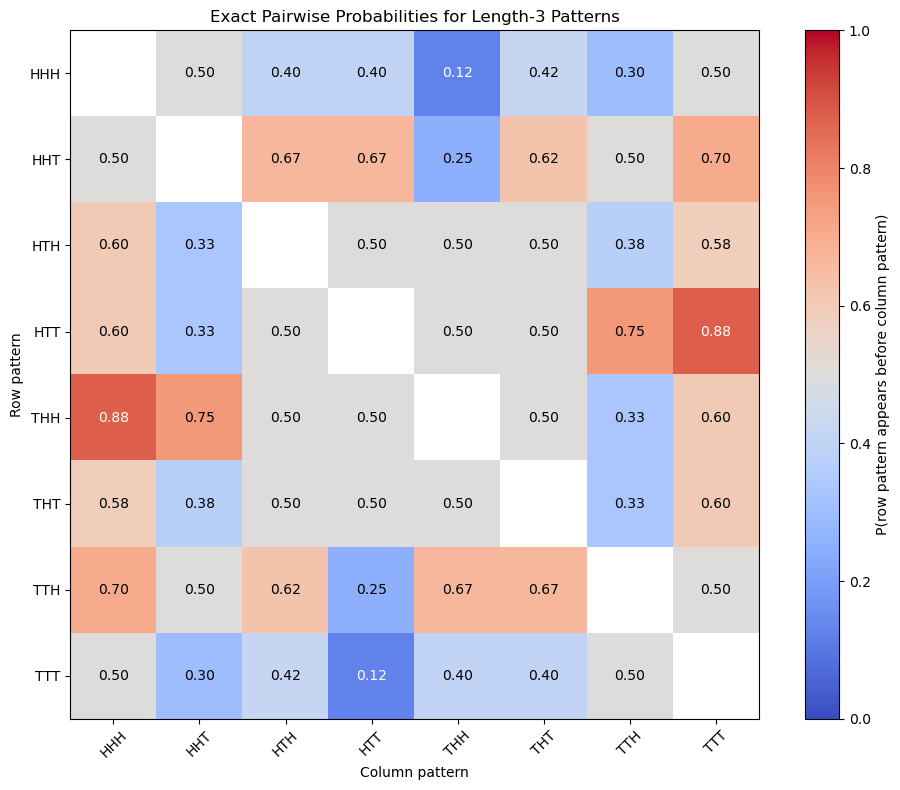

In [12]:
from itertools import product


patterns = [
    "".join(symbols)
    for symbols in product("HT", repeat=3)
]

probability_matrix = np.full(
    (len(patterns), len(patterns)),
    np.nan
)

for row, pattern1 in enumerate(patterns):
    for column, pattern2 in enumerate(patterns):
        if pattern1 != pattern2:
            probability_matrix[row, column] = (
                exact_winning_probability(
                    pattern1,
                    pattern2
                )
            )

plt.figure(figsize=(10, 8))

image = plt.imshow(
    probability_matrix,
    cmap="coolwarm",
    vmin=0,
    vmax=1
)

plt.colorbar(
    image,
    label="P(row pattern appears before column pattern)"
)

plt.xticks(
    range(len(patterns)),
    patterns,
    rotation=45
)

plt.yticks(
    range(len(patterns)),
    patterns
)

for row in range(len(patterns)):
    for column in range(len(patterns)):
        value = probability_matrix[row, column]

        if not np.isnan(value):
            text_color = (
                "white"
                if value < 0.25 or value > 0.75
                else "black"
            )

            plt.text(
                column,
                row,
                f"{value:.2f}",
                ha="center",
                va="center",
                color=text_color
            )

plt.xlabel("Column pattern")
plt.ylabel("Row pattern")
plt.title("Exact Pairwise Probabilities for Length-3 Patterns")
plt.tight_layout()
plt.show()

## Conclusion

Penney's game can be modelled as an absorbing Markov chain whose two
absorbing states correspond to the competing patterns.

For `HTH` against `HHT`, the exact probability that `HTH` appears first
is $1/3$. A Monte Carlo simulation with 100,000 trials produced an
estimate of $0.3331$, consistent with the exact result.

The pairwise probability matrix shows that the competition between
equal-length patterns is generally asymmetric because their prefix and
suffix overlaps produce different transition structures.